In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Name_BCM = "Learned_BCM"
time_now_BCM = "09:15"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "09:47"
date = "06-07"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_No_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

CPU times: user 2.2 s, sys: 2.11 s, total: 4.31 s
Wall time: 5.67 s


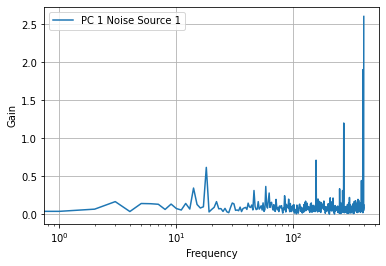

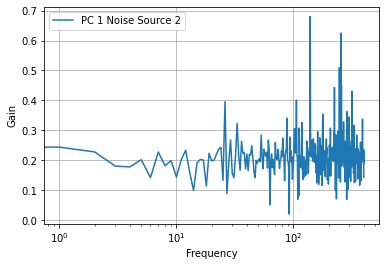

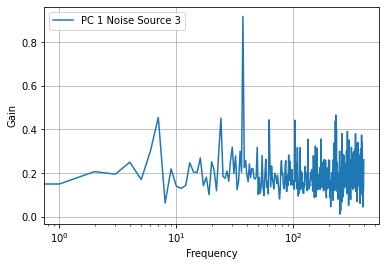

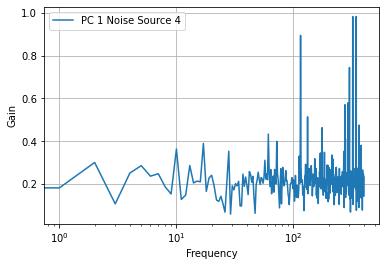

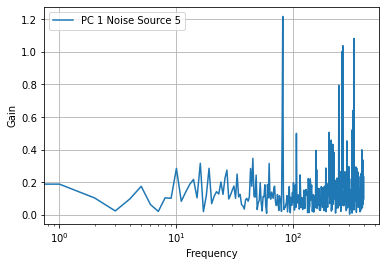

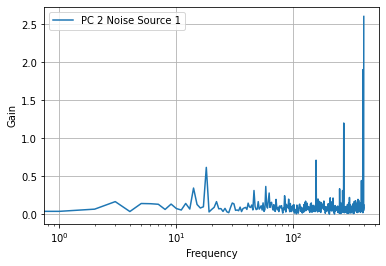

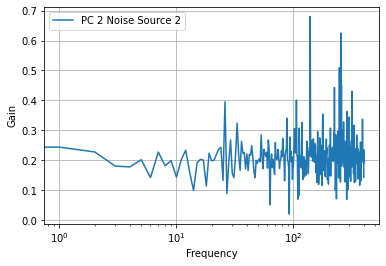

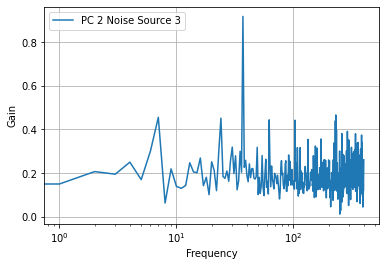

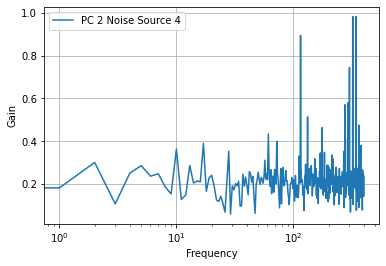

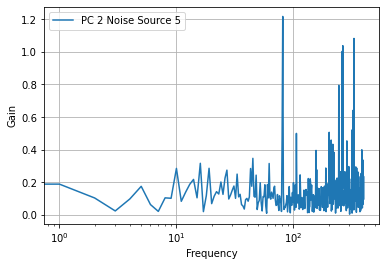

In [143]:
bb = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    kk = 0
    for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
        bb[ii].append(mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:]*Noise_No_BCM.I[kk]/nA/Params.N_Noise)
        kk+=1

start = 80
end = 120
        
for ii in range(0,Params.N_Cells_PC):
    for jj in range(0,Params.N_Noise):#Params.N_Noise):
        N = len(bb[ii][jj][start*20:end*20]) #600
        T = Params.dt_rec*second #1.0 / 800.0
        y2 = Noise_No_BCM.I[jj][start*20:end*20]/nA#np.linspace(0.0, N*T, N, endpoint=False)
        y = bb[ii][jj][start*20:end*20]#np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
        yf = fft(y2)
        yf2 = fft(y)
        asdf = np.abs(yf2 / yf)[:N//2]
        plt.plot(asdf, label = "PC "+str(ii+1)+" Noise Source "+str(jj+1))
    #     plt.yscale('log')
        plt.xscale('log')
        plt.xlabel('Frequency')
        plt.ylabel('Gain')
        plt.legend()
        plt.grid()
        plt.show()

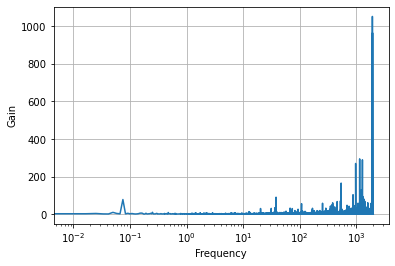

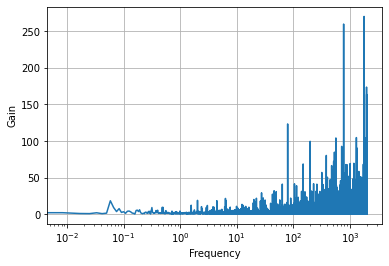

In [54]:
for ii in range(0,2):#Params.N_Noise):
    N = len(PC_No_BCM.I_Noise[ii]) #600
    T = Params.dt_rec*second #1.0 / 800.0
    y2 = PC_No_BCM.I_Noise[ii]/nA#np.linspace(0.0, N*T, N, endpoint=False)
    y = PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA#np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
    yf = fft(y2)
    yf2 = fft(y)
    asdf = np.abs(yf2 / yf)[:N//2]
    plt.plot(xf, asdf)
#     plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Frequency')
    plt.ylabel('Gain')
#     plt.legend()
    plt.grid()
    plt.show()